Inline backend: module://matplotlib_inline.backend_inline
Shape: (100, 6)
Class balance:
 target
0    50
1    50
Name: count, dtype: int64
Train: (80, 2) Test: (20, 2)

=== Kernel Comparison ===
Kernel  Accuracy  Precision  Recall     F1   AUC
linear      0.80     0.8750     0.7 0.7778 0.970
   rbf      0.85     0.8889     0.8 0.8421 0.970
  poly      0.75     1.0000     0.5 0.6667 0.975

=== BEST SVM PARAMETERS ===
{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 0.9875

=== TUNED SVM (RBF) ===
Accuracy : 0.8
Precision: 0.875
Recall   : 0.7
F1-score : 0.7778
AUC      : 0.97

Classification Report:
              precision    recall  f1-score   support

  versicolor       0.75      0.90      0.82        10
   virginica       0.88      0.70      0.78        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20

5-fold CV accuracy: [1.     0.9375 1.     1.     1.    ]


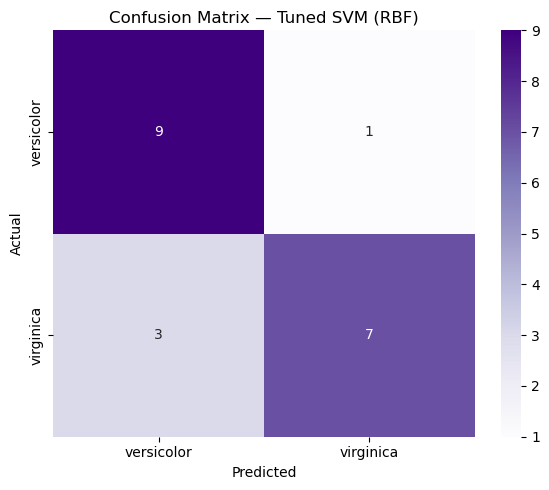

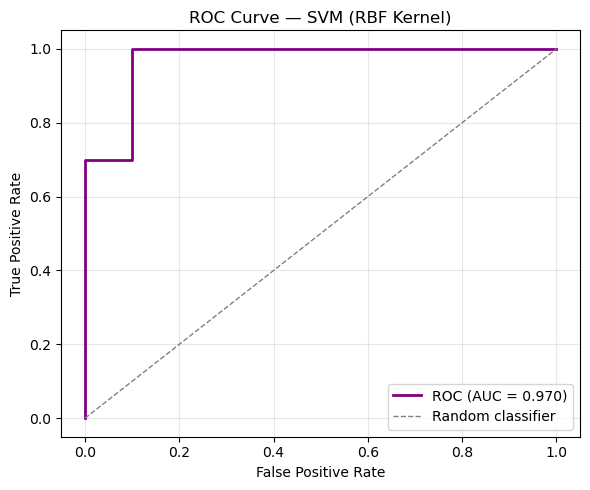

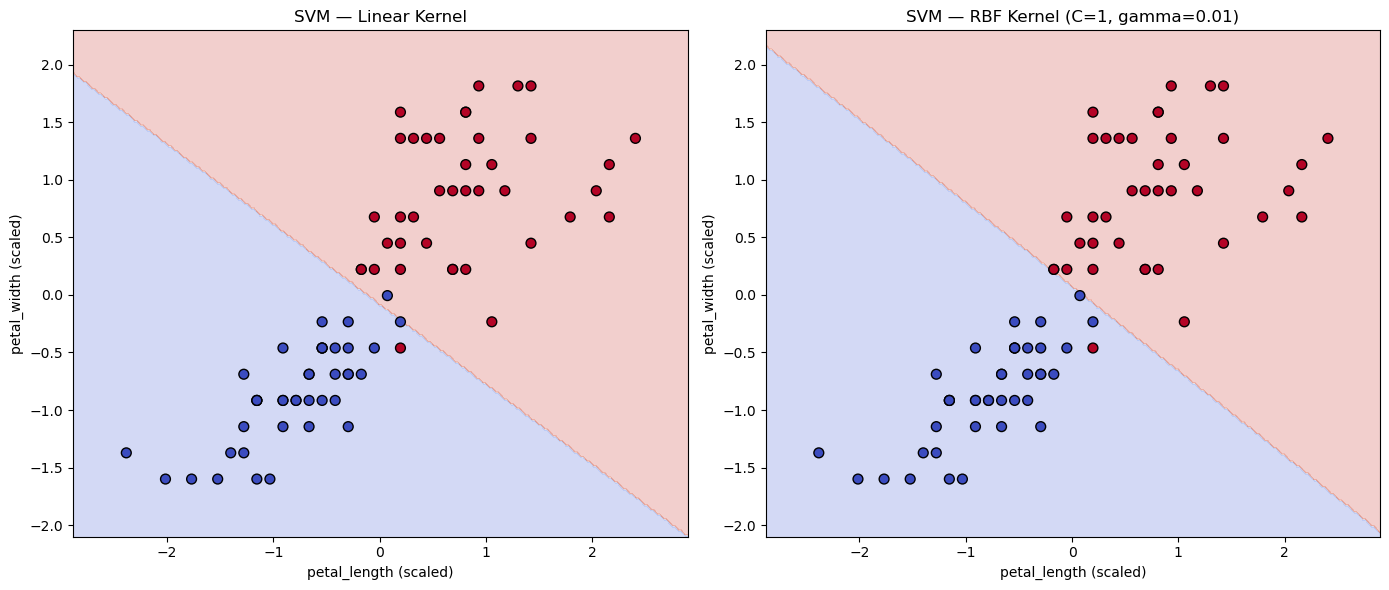


Support vectors per model:
  Linear SVM: 13 of 80 training samples
  RBF SVM   : 50 of 80 training samples

Saved images: ['confusion_matrix_svm.png', 'decision_boundary_svm.png', 'roc_curve_svm.png']


In [1]:
# =========================================================
# Support Vector Machine (SVM) — Binary Classification
# Codveda ML Internship — Level 3, Task 2
# =========================================================
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

# ---------------------------------------------------------
# Output folder
# ---------------------------------------------------------
os.makedirs("images", exist_ok=True)
print("Inline backend:", plt.get_backend())

# ---------------------------------------------------------
# 1. Load Iris and create a binary problem
# ---------------------------------------------------------
path = r"C:\Users\250 G7\Desktop\CodeVeda Intern\Dataset\1) iris.csv"
df = pd.read_csv(path)

# Keep only versicolor and virginica — the harder, non-linearly-separable pair
df_bin = df[df["species"].isin(["versicolor", "virginica"])].copy()
df_bin["target"] = (df_bin["species"] == "virginica").astype(int)

print("Shape:", df_bin.shape)
print("Class balance:\n", df_bin["target"].value_counts())

# ---------------------------------------------------------
# 2. Use just 2 features for decision-boundary visualization
#    (petal_length and petal_width give clean 2D separation)
# ---------------------------------------------------------
features = ["petal_length", "petal_width"]
X = df_bin[features].values
y = df_bin["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SVM is scale-sensitive → always standardize
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, "Test:", X_test_s.shape)

# ---------------------------------------------------------
# 3. Compare kernels (linear vs RBF vs poly)
# ---------------------------------------------------------
kernels = ["linear", "rbf", "poly"]
results = []

for k in kernels:
    model = SVC(kernel=k, probability=True, random_state=42)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]

    results.append({
        "Kernel": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results)
print("\n=== Kernel Comparison ===")
print(results_df.round(4).to_string(index=False))

# ---------------------------------------------------------
# 4. Tune C and gamma for RBF kernel via GridSearchCV
# ---------------------------------------------------------
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf"],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
)
grid.fit(X_train_s, y_train)

print("\n=== BEST SVM PARAMETERS ===")
print(grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

best_svm = grid.best_estimator_
y_pred_best = best_svm.predict(X_test_s)
y_prob_best = best_svm.predict_proba(X_test_s)[:, 1]

# ---------------------------------------------------------
# 5. Evaluate the tuned model
# ---------------------------------------------------------
print("\n=== TUNED SVM (RBF) ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_pred_best), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best), 4))
print("F1-score :", round(f1_score(y_test, y_pred_best), 4))
print("AUC      :", round(roc_auc_score(y_test, y_prob_best), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=["versicolor", "virginica"]))

# ---------------------------------------------------------
# 6. Cross-validation stability
# ---------------------------------------------------------
cv_scores = cross_val_score(best_svm, X_train_s, y_train, cv=cv, scoring="accuracy")
print("5-fold CV accuracy:", np.round(cv_scores, 4))
print("Mean:", round(cv_scores.mean(), 4), "| Std:", round(cv_scores.std(), 4))

# ---------------------------------------------------------
# 7. Confusion matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["versicolor", "virginica"],
            yticklabels=["versicolor", "virginica"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Tuned SVM (RBF)")
plt.tight_layout()
plt.savefig("images/confusion_matrix_svm.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 8. ROC curve
# ---------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="purple", lw=2,
         label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1,
         label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SVM (RBF Kernel)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/roc_curve_svm.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 9. Decision boundary — linear vs RBF (2D visualization)
# ---------------------------------------------------------
def plot_decision_boundary(model, X, y, title, ax):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm",
                        edgecolors="k", s=50)
    ax.set_xlabel("petal_length (scaled)")
    ax.set_ylabel("petal_width (scaled)")
    ax.set_title(title)

# Fit a plain linear SVM and a plain RBF SVM for the comparison plot
svm_linear = SVC(kernel="linear", probability=True, random_state=42).fit(X_train_s, y_train)
svm_rbf    = SVC(kernel="rbf", C=best_svm.C, gamma=best_svm.gamma,
                 probability=True, random_state=42).fit(X_train_s, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_boundary(svm_linear, X_train_s, y_train,
                       "SVM — Linear Kernel", axes[0])
plot_decision_boundary(svm_rbf, X_train_s, y_train,
                       f"SVM — RBF Kernel (C={best_svm.C}, gamma={best_svm.gamma})",
                       axes[1])
plt.tight_layout()
plt.savefig("images/decision_boundary_svm.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 10. Support vectors count (why SVM is memory-efficient)
# ---------------------------------------------------------
print("\nSupport vectors per model:")
print(f"  Linear SVM: {len(svm_linear.support_)} of {len(X_train_s)} training samples")
print(f"  RBF SVM   : {len(svm_rbf.support_)} of {len(X_train_s)} training samples")

# ---------------------------------------------------------
# 11. Verify saved images
# ---------------------------------------------------------
print("\nSaved images:", sorted(os.listdir("images")))